# Notebook Purpose

Create and validate user, product, and interaction features for reorder prediction.


In [2]:
# ========================================
# Cell 1: Imports and Setup
# ========================================
import sys
sys.path.append('..')

from src.features.feature_engineering import FeatureEngineer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("✅ Imports successful")


✅ Imports successful


In [3]:
# ========================================
# Cell 2: Load Prior Data
# ========================================
prior_data = pd.read_parquet('../data/processed/prior_orders.parquet')

print(f"Prior data shape: {prior_data.shape}")
print(f"Columns: {prior_data.columns.tolist()}")
print(f"\nSample:")
print(prior_data.head())


Prior data shape: (32434489, 9)
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']

Sample:
   order_id  product_id  add_to_cart_order  reordered  user_id  order_number  \
0         2       33120                  1          1   202279             3   
1         2       28985                  2          1   202279             3   
2         2        9327                  3          0   202279             3   
3         2       45918                  4          1   202279             3   
4         2       30035                  5          0   202279             3   

   order_dow  order_hour_of_day  days_since_prior_order  
0          5                  9                     8.0  
1          5                  9                     8.0  
2          5                  9                     8.0  
3          5                  9                     8.0  
4          5                  9

In [4]:
# Cell 3: Create features with expanded feature set

import sys
sys.path.append('..')

from src.features.feature_engineering import FeatureEngineer
import pandas as pd

# Load prior data
prior_data = pd.read_parquet('../data/processed/prior_orders.parquet')

# Load products for department/aisle features
products = pd.read_csv('../data/raw/products.csv')

print(f"Prior data shape: {prior_data.shape}")
print(f"Products: {len(products)}")

# Create features with expanded feature set
fe = FeatureEngineer()
results = fe.create_all_features(prior_data, products)

# Unpack results
if len(results) == 6:
    user_feat, product_feat, up_feat, dept_feat, aisle_feat, user_dept_feat = results
    has_dept_features = True
else:
    user_feat, product_feat, up_feat = results
    has_dept_features = False

# Save features
import os
os.makedirs('../data/features', exist_ok=True)

user_feat.to_csv('../data/features/user_features.csv', index=False)
product_feat.to_csv('../data/features/product_features.csv', index=False)
up_feat.to_csv('../data/features/user_product_features.csv', index=False)

if has_dept_features:
    dept_feat.to_csv('../data/features/department_features.csv', index=False)
    aisle_feat.to_csv('../data/features/aisle_features.csv', index=False)
    user_dept_feat.to_csv('../data/features/user_department_features.csv', index=False)
    print("\n✅ All features (including dept/aisle) saved!")
else:
    print("\n✅ Basic features saved!")


Prior data shape: (32434489, 9)
Products: 49688

FEATURE ENGINEERING - EXPANDED VERSION

Creating user features...
✅ Created 206209 user feature rows
   Features: 9
Creating product features...
✅ Created 49677 product feature rows
   Features: 7
Creating user-product interaction features...
✅ Created 13307953 user-product pairs
   Features: 13
Creating order streak features...
✅ Created streak features for 13307953 user-product pairs
Creating department and aisle features...
✅ Created department features: 21 rows
✅ Created aisle features: 134 rows
Creating user-department interaction features...
✅ Created 2232789 user-department pairs

FEATURE SUMMARY
User features: 9
Product features: 7
User-Product features: 15
Department features: 3
Aisle features: 3
User-Department features: 3

Total features: 41

✅ All features (including dept/aisle) saved!


In [4]:
# ========================================
# Cell 4: Save Features
# ========================================
import os
os.makedirs('../data/features', exist_ok=True)

user_feat.to_csv('../data/features/user_features.csv', index=False)
product_feat.to_csv('../data/features/product_features.csv', index=False)
up_feat.to_csv('../data/features/user_product_features.csv', index=False)

print("✅ All features saved!")
print(f"  - User features: {user_feat.shape}")
print(f"  - Product features: {product_feat.shape}")
print(f"  - User-Product features: {up_feat.shape}")


✅ All features saved!
  - User features: (206209, 8)
  - Product features: (49677, 5)
  - User-Product features: (13307953, 10)


In [5]:
# ========================================
# Cell 5: Explore User Features
# ========================================
print("=" * 60)
print("USER FEATURES")
print("=" * 60)

print("\nSample:")
print(user_feat.head(10))

print("\nDescriptive Statistics:")
print(user_feat.describe())

print("\nFeature List:")
for col in user_feat.columns:
    print(f"  - {col}")


USER FEATURES

Sample:
   user_id  user_total_orders  user_total_products  user_reorder_ratio  \
0        1                 10                   59            0.694915   
1        2                 14                  195            0.476923   
2        3                 12                   88            0.625000   
3        4                  5                   18            0.055556   
4        5                  4                   37            0.378378   
5        6                  3                   14            0.142857   
6        7                 20                  206            0.669903   
7        8                  3                   49            0.265306   
8        9                  3                   76            0.236842   
9       10                  5                  143            0.342657   

   user_avg_days_between_orders  user_favorite_dow  user_favorite_hour  \
0                     20.259259                  4                   7   
1             

In [6]:
# ========================================
# Cell 6: Explore Product Features
# ========================================
print("=" * 60)
print("PRODUCT FEATURES")
print("=" * 60)

print("\nSample:")
print(product_feat.head(10))

print("\nDescriptive Statistics:")
print(product_feat.describe())

# Top 10 most popular products
print("\nTop 10 Most Ordered Products:")
print(product_feat.nlargest(10, 'product_orders')[
    ['product_id', 'product_orders', 'product_reorder_ratio']
])


PRODUCT FEATURES

Sample:
   product_id  product_orders  product_reorder_ratio  \
0           1            1852               0.613391   
1           2              90               0.133333   
2           3             277               0.732852   
3           4             329               0.446809   
4           5              15               0.600000   
5           6               8               0.375000   
6           7              30               0.400000   
7           8             165               0.503030   
8           9             156               0.525641   
9          10            2572               0.506998   

   product_avg_cart_position  product_unique_users  
0                   5.801836                   716  
1                   9.888889                    78  
2                   6.415162                    74  
3                   9.507599                   182  
4                   6.466667                     6  
5                  14.125000           

In [7]:
# ========================================
# Cell 7: Explore User-Product Features
# ========================================
print("=" * 60)
print("USER-PRODUCT INTERACTION FEATURES")
print("=" * 60)

print("\nSample:")
print(up_feat.head(10))

print("\nDescriptive Statistics:")
print(up_feat.describe())

# Examples of user with many purchases
sample_user = up_feat.groupby('user_id')['up_times_bought'].sum().idxmax()
print(f"\nExample: User {sample_user}'s purchases:")
print(up_feat[up_feat['user_id'] == sample_user].head(10))


USER-PRODUCT INTERACTION FEATURES

Sample:
   user_id  product_id  up_times_bought  up_last_order_number  \
0        1         196               10                    10   
1        1       10258                9                    10   
2        1       10326                1                     5   
3        1       12427               10                    10   
4        1       13032                3                    10   
5        1       13176                2                     5   
6        1       14084                1                     1   
7        1       17122                1                     5   
8        1       25133                8                    10   
9        1       26088                2                     2   

   up_first_order_number  up_avg_cart_position  up_reorder_ratio  \
0                      1              1.400000          0.900000   
1                      2              3.333333          0.888889   
2                      5             

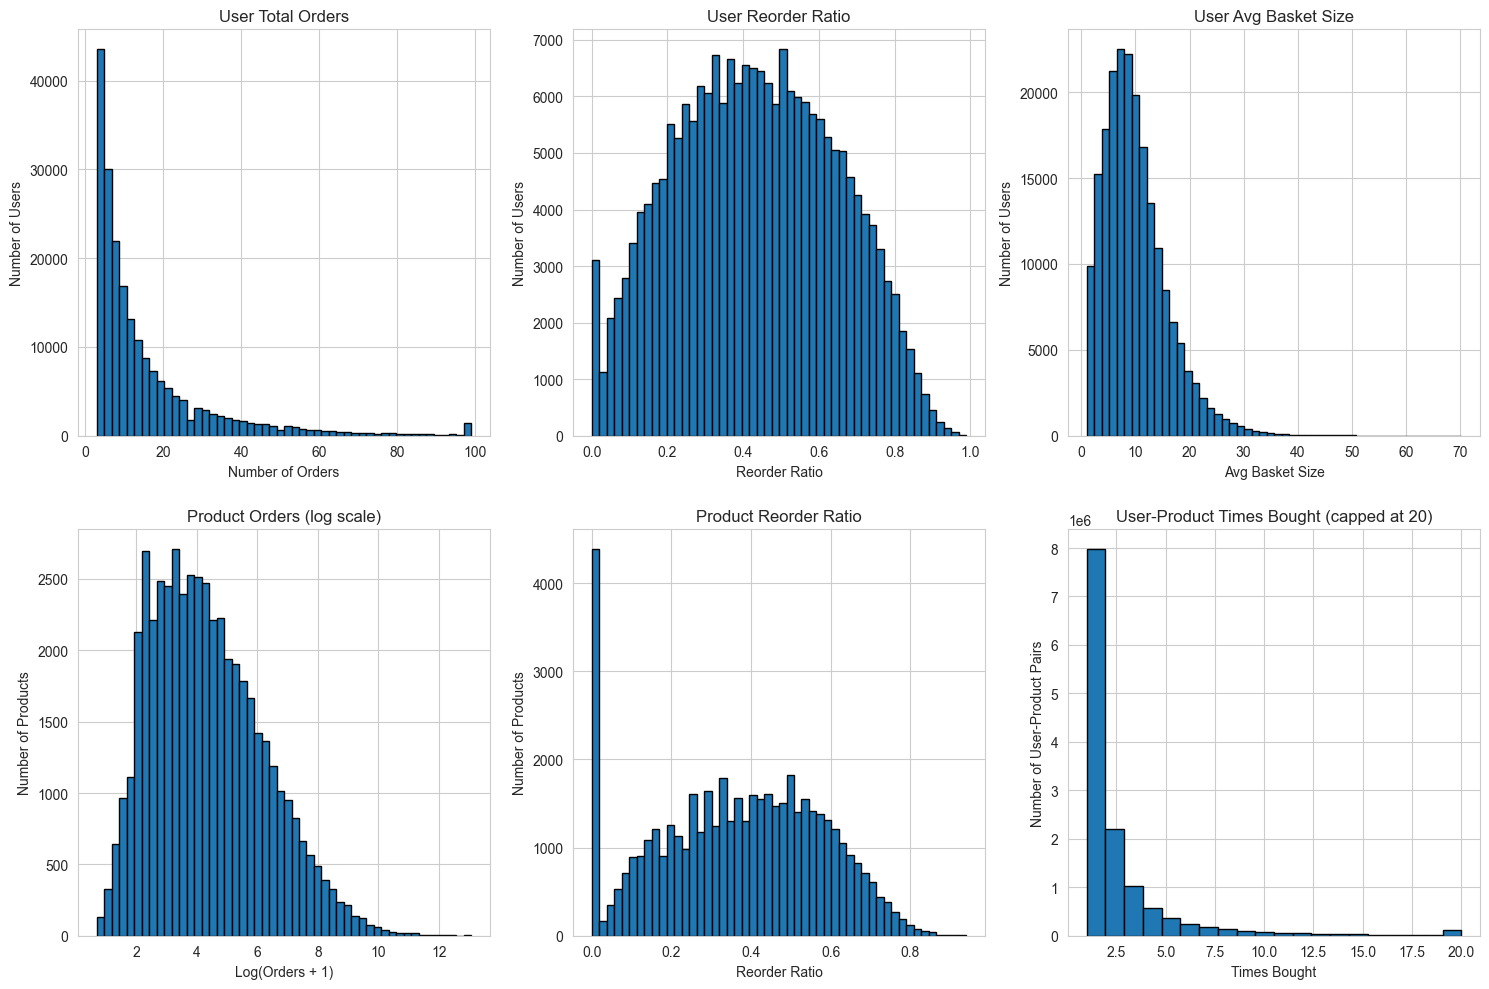

✅ Feature distribution plots saved!


In [10]:
# ========================================
# Cell 8: Feature distributions
# ========================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# User features
axes[0,0].hist(user_feat['user_total_orders'], bins=50, edgecolor='black')
axes[0,0].set_title('User Total Orders')
axes[0,0].set_xlabel('Number of Orders')
axes[0,0].set_ylabel('Number of Users')

axes[0,1].hist(user_feat['user_reorder_ratio'], bins=50, edgecolor='black')
axes[0,1].set_title('User Reorder Ratio')
axes[0,1].set_xlabel('Reorder Ratio')
axes[0,1].set_ylabel('Number of Users')

axes[0,2].hist(user_feat['user_avg_basket_size'], bins=50, edgecolor='black')
axes[0,2].set_title('User Avg Basket Size')
axes[0,2].set_xlabel('Avg Basket Size')
axes[0,2].set_ylabel('Number of Users')

# Product features
axes[1,0].hist(np.log1p(product_feat['product_orders']), bins=50, edgecolor='black')
axes[1,0].set_title('Product Orders (log scale)')
axes[1,0].set_xlabel('Log(Orders + 1)')
axes[1,0].set_ylabel('Number of Products')

axes[1,1].hist(product_feat['product_reorder_ratio'], bins=50, edgecolor='black')
axes[1,1].set_title('Product Reorder Ratio')
axes[1,1].set_xlabel('Reorder Ratio')
axes[1,1].set_ylabel('Number of Products')

# User-product features
axes[1,2].hist(up_feat['up_times_bought'].clip(upper=20), bins=20, edgecolor='black')
axes[1,2].set_title('User-Product Times Bought (capped at 20)')
axes[1,2].set_xlabel('Times Bought')
axes[1,2].set_ylabel('Number of User-Product Pairs')

plt.tight_layout()
plt.savefig('../notebooks/figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Feature distribution plots saved!")


User Feature Correlations:


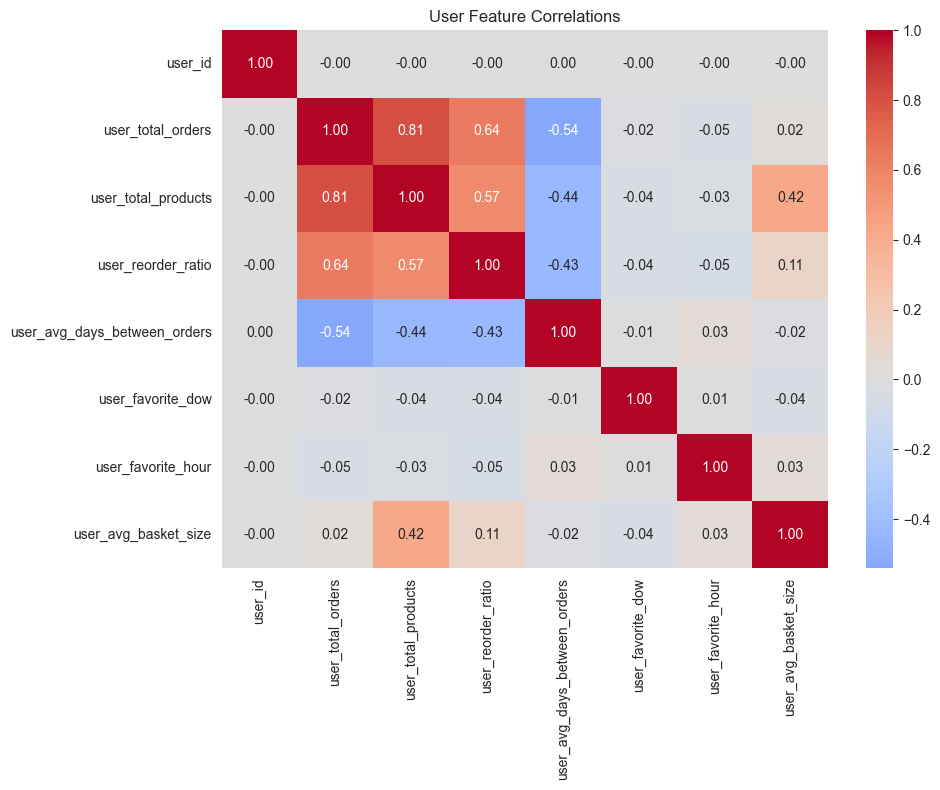

In [11]:
# ========================================
# Cell 9: Feature Correlations
# ========================================

# Look at correlations in user features
print("User Feature Correlations:")
user_corr = user_feat.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(user_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('User Feature Correlations')
plt.tight_layout()
plt.savefig('../notebooks/figures/user_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# ========================================
# Cell 10: Key Insights Summary
# ========================================

print("=" * 60)
print("KEY FEATURE INSIGHTS")
print("=" * 60)

print("\n📊 User Features:")
print(f"  - Average orders per user: {user_feat['user_total_orders'].mean():.1f}")
print(f"  - Average reorder ratio: {user_feat['user_reorder_ratio'].mean():.1%}")
print(f"  - Average basket size: {user_feat['user_avg_basket_size'].mean():.1f}")

print("\n📦 Product Features:")
print(f"  - Average orders per product: {product_feat['product_orders'].mean():.0f}")
print(f"  - Median orders per product: {product_feat['product_orders'].median():.0f}")
print(f"  - Average product reorder ratio: {product_feat['product_reorder_ratio'].mean():.1%}")

print("\n🔗 User-Product Interactions:")
print(f"  - Total user-product pairs: {len(up_feat):,}")
print(f"  - Average times bought: {up_feat['up_times_bought'].mean():.2f}")
print(f"  - Median times bought: {up_feat['up_times_bought'].median():.0f}")
print(f"  - Max times bought: {up_feat['up_times_bought'].max()}")

print("\n💡 Implications for Modeling:")
print("  - High user reorder ratio → User behavior is predictable")
print("  - High product reorder ratio → Products have loyal customers")
print("  - 13M user-product pairs → Need efficient model (e.g., LightGBM)")


KEY FEATURE INSIGHTS

📊 User Features:
  - Average orders per user: 15.6
  - Average reorder ratio: 43.2%
  - Average basket size: 10.0

📦 Product Features:
  - Average orders per product: 653
  - Median orders per product: 60
  - Average product reorder ratio: 36.6%

🔗 User-Product Interactions:
  - Total user-product pairs: 13,307,953
  - Average times bought: 2.44
  - Median times bought: 1
  - Max times bought: 99

💡 Implications for Modeling:
  - High user reorder ratio → User behavior is predictable
  - High product reorder ratio → Products have loyal customers
  - 13M user-product pairs → Need efficient model (e.g., LightGBM)


## Feature Engineering Summary

### Created Features

**User Features (7):**
- `user_total_orders`: Total orders placed
- `user_total_products`: Total products purchased
- `user_reorder_ratio`: What % of purchases are reorders
- `user_avg_days_between_orders`: Shopping frequency
- `user_favorite_dow`: Preferred day of week
- `user_favorite_hour`: Preferred hour
- `user_avg_basket_size`: Average items per order

**Product Features (4):**
- `product_orders`: How many times ordered
- `product_reorder_ratio`: How often it's reordered
- `product_avg_cart_position`: Average position in cart
- `product_unique_users`: How many users bought it

**User-Product Features (9):**
- `up_times_bought`: How many times user bought this product
- `up_last_order_number`: User's last order with this product
- `up_first_order_number`: User's first order with this product
- `up_avg_cart_position`: Avg position when user buys it
- `up_reorder_ratio`: Reorder ratio for this specific pair
- `up_orders_since_last`: Orders since user last bought it
- `up_order_range`: Spread of orders (last - first)
- `up_purchase_frequency`: Frequency of purchase

### Next Steps
1. Create training dataset by combining features with labels
2. Build baseline model
3. Evaluate and iterate